# Stock Trading Recommending System Using Enhanced LSTM with Peak Valley Algorithm
## Overview
This notebook builds a smart trading system for Apple Inc. (AAPL) stock leveraging machine learning and algorithmic techniques. Using an LSTM (Long Short-Term Memory) model, it predicts stock prices to guide buy/sell decisions based on price trends and trading volume.

## Key Features
1.Data fetching from Polygon.io API for hourly AAPL stock prices (Open, Close, Volume)

2.Data preprocessing and cleaning using Pandas and MinMaxScaler

3.Feature engineering and time-series sequence preparation with lookback windows

4.Implementation of a Peak Valley Algorithm to identify significant price highs and lows triggering trade signals

5.LSTM neural network design, training, and validation with custom callbacks to monitor model accuracy

6.Visualization of price trends, volume patterns, returns distribution, and model training metrics using Matplotlib and Seaborn

7.Streamlit dashboard integration showcasing portfolio growth, profit trends, and real-time trade signals

8.Detailed exploratory data analysis (EDA) with correlation heatmaps, moving averages, volatility bands, and autocorrelation plots

## Objectives
1.To predict future stock prices for AAPL robustly using historical data sequences

2.To enable algorithmic trade execution based on ML-driven insights from price peaks and valleys

3.To provide visual and quantitative evaluation of both data and model performance

4.To prepare a deployable system offering actionable trading recommendations and risk analytics

## Contents
1.Data Fetching and Preparation

2.Exploratory Data Analysis (EDA) and Visualization

3.LSTM Model Architecture and Training

4.Model Performance Analysis and Accuracy Metrics

5.Trading Signal Generation via Peak Valley Algorithm

6.Dashboard and User Interface

In [19]:
import pandas as pd
stock_df = pd.read_csv('raw_aapl.csv')
print(stock_df.describe())
print(stock_df.info())


              Open        Close        Volume
count  4001.000000  4001.000000  4.001000e+03
mean    221.813634   221.820458  2.842018e+06
std      17.902730    17.892825  4.125175e+06
min     169.280000   168.800000  8.160000e+02
25%     213.260000   213.260200  4.135200e+04
50%     224.830000   224.820000  1.055193e+06
75%     232.860000   232.870000  4.471988e+06
max     259.120000   259.280000  6.414249e+07
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4001 non-null   object 
 1   Open    4001 non-null   float64
 2   Close   4001 non-null   float64
 3   Volume  4001 non-null   float64
dtypes: float64(3), object(1)
memory usage: 125.2+ KB
None


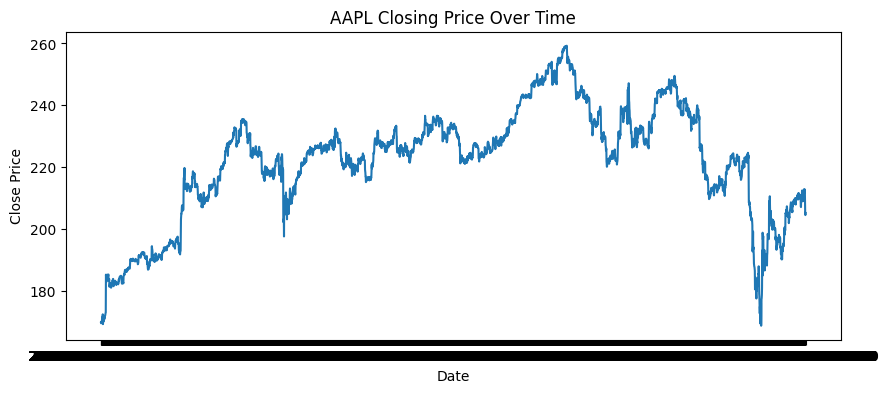

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(stock_df['Date'], stock_df['Close'])
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


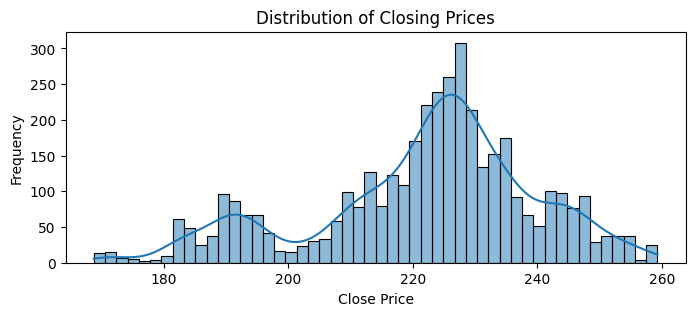

In [21]:

import seaborn as sns
plt.figure(figsize=(8, 3))
sns.histplot(stock_df['Close'], bins=50, kde=True)
plt.title('Distribution of Closing Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()


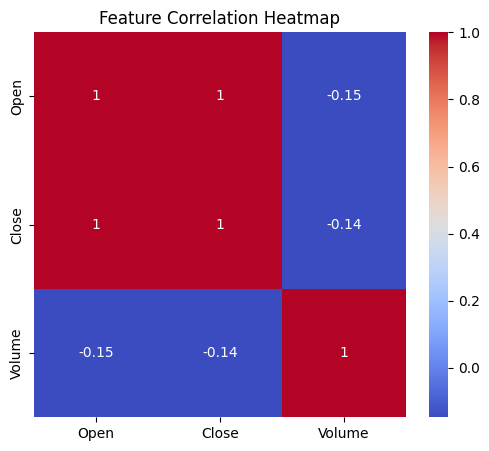

In [22]:
plt.figure(figsize=(6,5))
sns.heatmap(stock_df[['Open','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


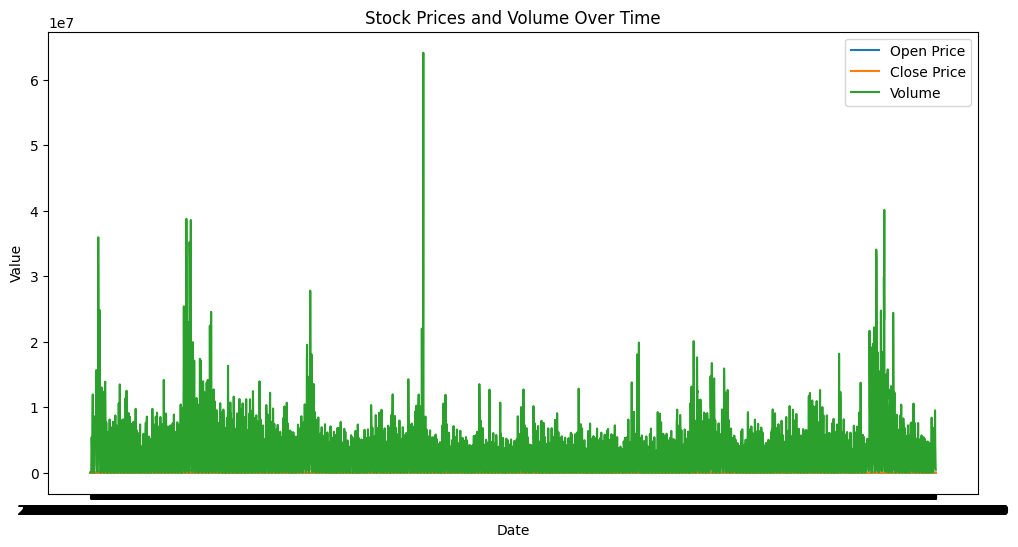

In [23]:
df = pd.read_csv('raw_aapl.csv') 
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Open'], label='Open Price')
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['Volume'], label='Volume')
plt.title('Stock Prices and Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()


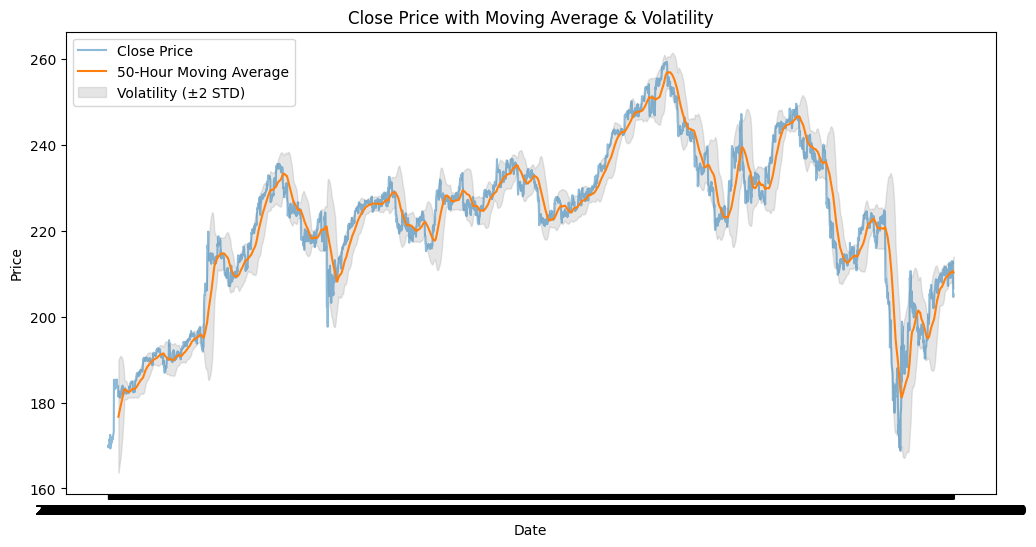

In [24]:
window = 50  # Example window size for moving average

df['Close_MA'] = df['Close'].rolling(window=window).mean()
df['Close_STD'] = df['Close'].rolling(window=window).std()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', alpha=0.5)
plt.plot(df['Date'], df['Close_MA'], label=f'{window}-Hour Moving Average')
plt.fill_between(df['Date'], 
                 df['Close_MA'] - 2*df['Close_STD'], 
                 df['Close_MA'] + 2*df['Close_STD'], 
                 color='gray', alpha=0.2, label='Volatility (±2 STD)')
plt.title('Close Price with Moving Average & Volatility')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [25]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(8, 4))
autocorrelation_plot(df['Return'].dropna())
plt.title('Autocorrelation of Returns')
plt.show()


KeyError: 'Return'

<Figure size 800x400 with 0 Axes>

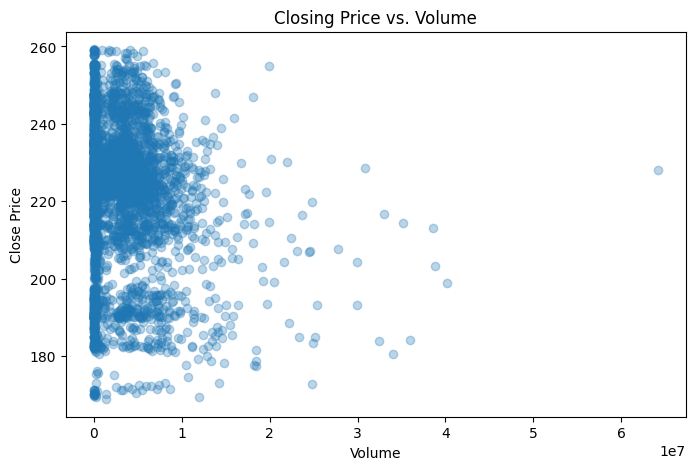

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Volume'], df['Close'], alpha=0.3)
plt.title('Closing Price vs. Volume')
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.show()
